<a href="https://colab.research.google.com/github/Sayandt-web/Reconstruction-and-Classification-of-Brain-Strokes-Using-Deep-learning-based-microwave-imaging/blob/main/Reconstruction_and_Classification_of_Brain_Strokes_Using_Deep_learning_based_microwave_imaging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Reconstruction and Classification of Brain Strokes
Using Deep learning-based microwave imaging
(SAYYED SALEH SAYYED MOUSAVI)

https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=10870242

Building Green's function matrices...
Done.
Generating dataset and running DBIM (this may take a few minutes)...
Generated 20/100
Generated 40/100
Generated 60/100
Generated 80/100
Generated 100/100
Using device: cuda
Training U‑Net...
Epoch 10/60, Train Loss: -4.4369, Val Loss: 7013500.5000
Epoch 20/60, Train Loss: -6.3602, Val Loss: 611223968.0000
Epoch 30/60, Train Loss: -7.2477, Val Loss: 1081692800.0000
Epoch 40/60, Train Loss: -7.5700, Val Loss: 4353986304.0000
Epoch 50/60, Train Loss: -7.6664, Val Loss: 4369289728.0000
Epoch 60/60, Train Loss: -7.7858, Val Loss: 5024556288.0000


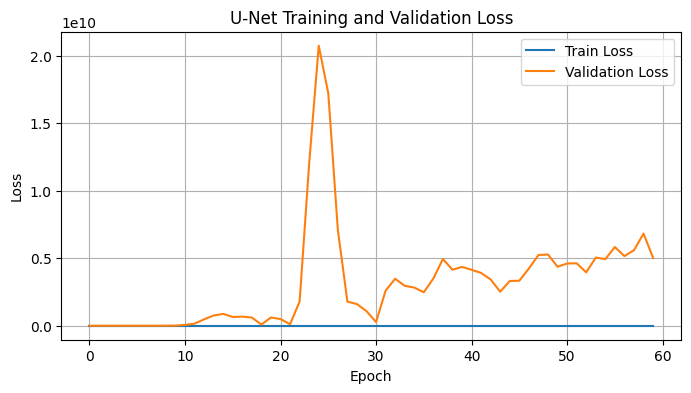

Training CNN classifier...
Epoch 10/60, Train Loss: 0.6969, Train Acc: 52.86%, Val Loss: 0.6713, Val Acc: 73.33%
Epoch 20/60, Train Loss: 0.6904, Train Acc: 51.43%, Val Loss: 0.6905, Val Acc: 73.33%
Epoch 30/60, Train Loss: 0.6932, Train Acc: 57.14%, Val Loss: 0.7033, Val Acc: 26.67%
Epoch 40/60, Train Loss: 0.6924, Train Acc: 51.43%, Val Loss: 0.6941, Val Acc: 26.67%
Epoch 50/60, Train Loss: 0.6899, Train Acc: 51.43%, Val Loss: 0.6945, Val Acc: 26.67%
Epoch 60/60, Train Loss: 0.6931, Train Acc: 42.86%, Val Loss: 0.7083, Val Acc: 26.67%


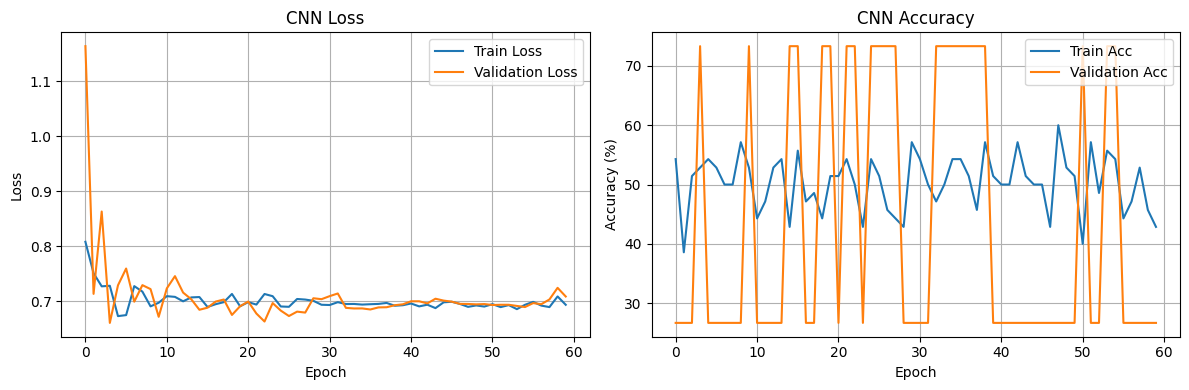

Test Accuracy: 46.67%


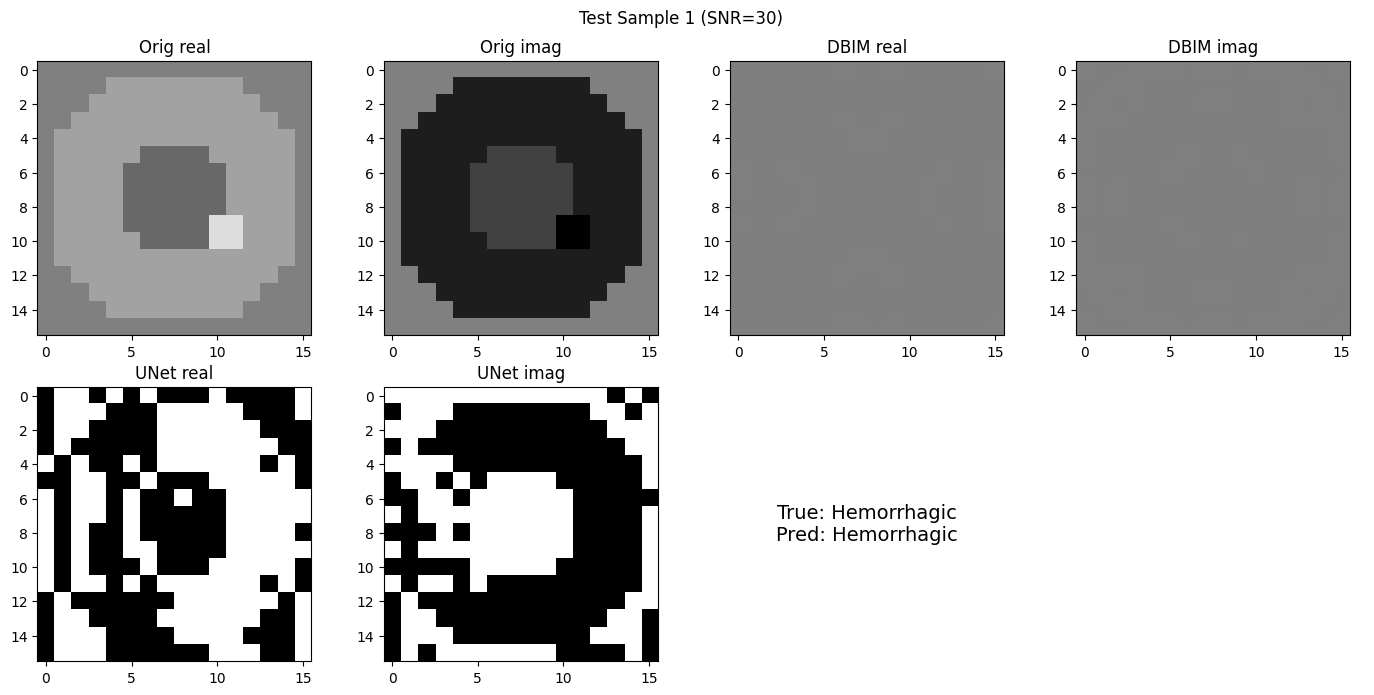

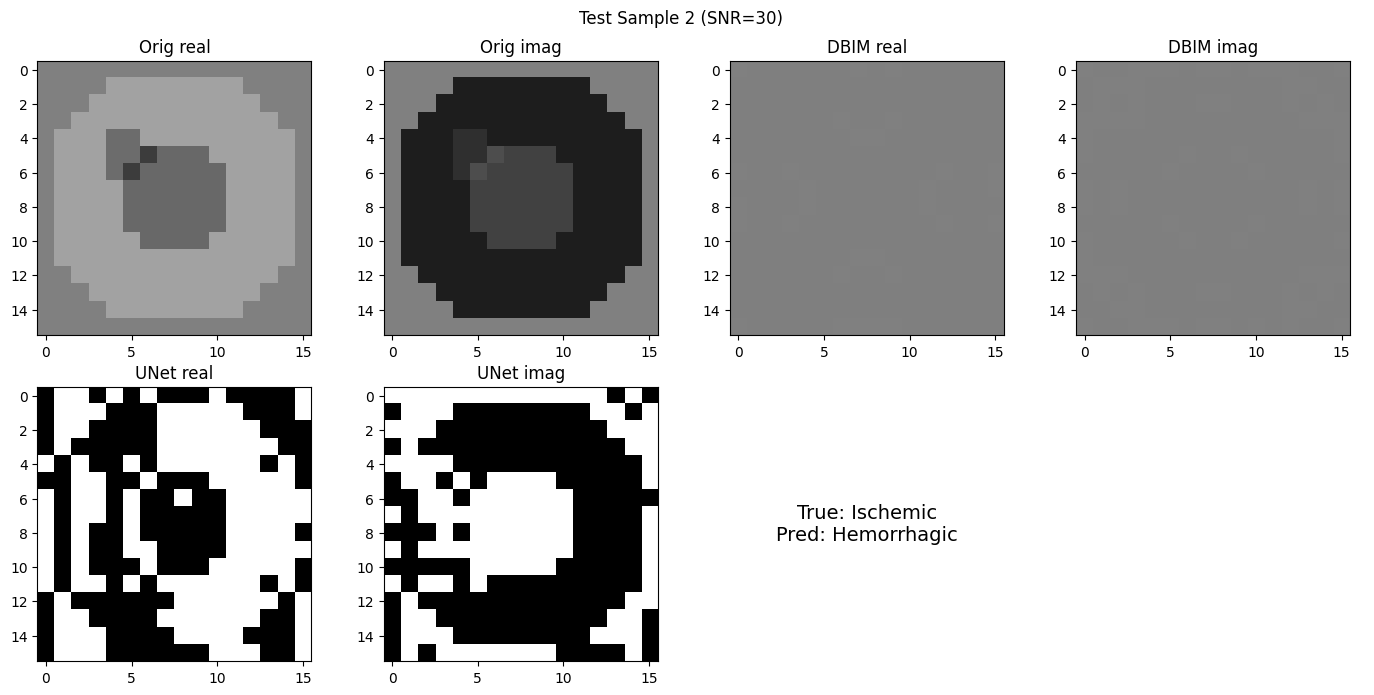

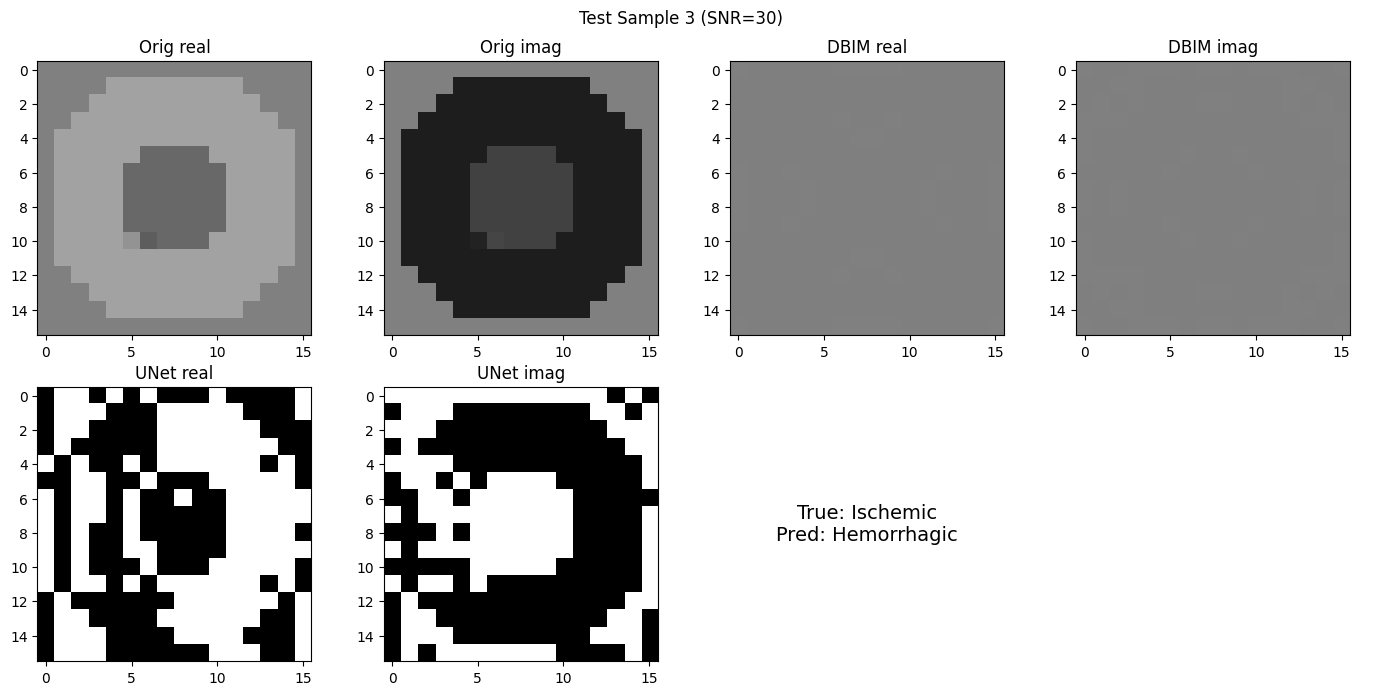

In [ ]:
# =============================================================================
# Full implementation of:
# "Reconstruction and Classification of Brain Strokes Using Deep learning-based
# microwave imaging" – Sayyed Mousavi & Majedi
# =============================================================================
# This code runs on Google Colab with PyTorch and standard scientific libraries.
# It generates synthetic data, runs DBIM, trains U‑Net and CNN, and displays
# images of the results.
# =============================================================================

import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from scipy.linalg import solve
import time
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ---------------------------
# 1.  Physics and Reconstruction (DBIM)
# ---------------------------

def green_2d(r, rp, k0):
    """2D Green's function: -1j/4 * H0^(2)(k0 * |r-rp|)"""
    dist = np.linalg.norm(r - rp)
    if dist < 1e-12:
        # Regularized value for zero distance
        return -1j / 4 * (1 - 2j / np.pi * (np.log(k0 * 1e-12 / 2) + 0.5772))
    return -1j / 4 * sp.hankel2(0, k0 * dist)

def build_matrices(pixels, receivers, transmitters, k0):
    """
    Build G_D (N x N) and G_s (R x N) matrices.
    pixels: list of pixel centers (N,2)
    receivers: list of receiver positions (R,2)
    transmitters: list of transmitter positions (T,2)
    """
    N = len(pixels)
    R = len(receivers)
    GD = np.zeros((N, N), dtype=complex)
    Gs = np.zeros((R, N), dtype=complex)
    for i, pi in enumerate(pixels):
        for j, pj in enumerate(pixels):
            GD[i, j] = green_2d(pi, pj, k0)
        for r, rec in enumerate(receivers):
            Gs[r, i] = green_2d(rec, pi, k0)
    return GD, Gs

def forward_solver(GD, chi, E_inc):
    """
    Solve state equation: (I - GD * diag(chi)) * E_tot = E_inc
    Returns E_tot (N x T)
    """
    N = chi.shape[0]
    T = E_inc.shape[1]
    A = np.eye(N, dtype=complex) - GD @ np.diag(chi)
    E_tot = np.zeros((N, T), dtype=complex)
    for t in range(T):
        E_tot[:, t] = solve(A, E_inc[:, t])
    return E_tot

def dbim_reconstruct(E_scat, GD, Gs, E_inc, chi_init=None, lambda_reg=0.01, max_iter=5):
    """
    Improved DBIM with generalized Tikhonov regularization.
    Returns reconstructed contrast (real = permittivity contrast, imag = conductivity contrast)
    """
    N = GD.shape[0]
    T = E_inc.shape[1]
    if chi_init is None:
        chi = np.zeros(N, dtype=complex)
    else:
        chi = chi_init.copy()

    for it in range(max_iter):
        # Total field
        E_tot = forward_solver(GD, chi, E_inc)                 # (N, T)
        # Predicted scattered field
        E_s_pred = Gs @ (chi[:, np.newaxis] * E_tot)           # (R, T)
        resid = E_scat - E_s_pred                              # (R, T)

        # Inhomogeneous Green's function from sources to receivers
        invA = np.linalg.inv(np.eye(N, dtype=complex) - GD @ np.diag(chi))
        G_bs = Gs @ invA                                       # (R, N)

        # Solve for delta chi using normal equations with regularization
        dchi = np.zeros(N, dtype=complex)
        for t in range(T):
            Jt = G_bs * E_tot[:, t]                            # (R, N) * (N,) -> (R, N)
            JtH = Jt.conj().T                                  # (N, R)
            A = JtH @ Jt + lambda_reg * np.eye(N, dtype=complex)  # (N, N)
            b = JtH @ resid[:, t]                              # (N,)
            dchi += solve(A, b)
        dchi = dchi / T                                        # average over transmitters

        chi = chi + dchi
        # enforce physical bounds (real part >= -1)
        chi = np.maximum(chi, -1 + 1e-6)
        # Optional: stop if residual small
        res_norm = np.linalg.norm(resid)
        if res_norm < 1e-6:
            break
    return chi

def generate_phantom(size, stroke_type, stroke_pos=None, stroke_radius=None):
    """
    Create a 2D brain phantom with a stroke.
    size: (Nx, Ny) pixels.
    stroke_type: 'hemorrhagic' or 'ischemic'
    Returns permittivity and conductivity maps (real values) and contrast.
    """
    Nx, Ny = size
    x = np.linspace(-1, 1, Nx)
    y = np.linspace(-1, 1, Ny)
    X, Y = np.meshgrid(x, y, indexing='ij')
    # Head: ellipse
    head = (X/1.0)**2 + (Y/1.0)**2 <= 1.0
    # White matter (inner ellipse) and gray matter
    white = (X/0.6)**2 + (Y/0.6)**2 <= 0.5
    gray = head & ~white

    # Permittivity and conductivity at 0.85 GHz
    eps_b = 44.0
    eps_gray = 50.0
    sigma_gray = 0.8
    eps_white = 40.0
    sigma_white = 0.5
    eps_blood = 60.0
    sigma_blood = 1.2

    eps = np.ones((Nx, Ny)) * eps_b
    sigma = np.zeros((Nx, Ny))
    eps[gray] = eps_gray
    sigma[gray] = sigma_gray
    eps[white] = eps_white
    sigma[white] = sigma_white

    # Add stroke
    if stroke_pos is None:
        stroke_pos = (np.random.uniform(-0.5, 0.5), np.random.uniform(-0.5, 0.5))
    if stroke_radius is None:
        stroke_radius = np.random.uniform(0.08, 0.2)
    stroke = (X - stroke_pos[0])**2 + (Y - stroke_pos[1])**2 <= stroke_radius**2

    if stroke_type == 'hemorrhagic':
        eps[stroke] = eps_blood
        sigma[stroke] = sigma_blood
    else:  # ischemic
        reduction = np.random.normal(0.17, 0.07)
        base_eps = eps.copy()
        base_sigma = sigma.copy()
        eps[stroke] = base_eps[stroke] * (1 - reduction)
        sigma[stroke] = base_sigma[stroke] * (1 - reduction)

    # Compute contrast: chi = (eps_r / eps_b - 1) - j * sigma / (omega * eps0 * eps_b)
    omega = 2 * np.pi * 0.85e9
    eps0 = 8.854e-12
    chi_real = eps / eps_b - 1.0
    chi_imag = - sigma / (omega * eps0 * eps_b)

    return eps, sigma, chi_real, chi_imag, stroke

def simulate_scattering(chi_real, chi_imag, GD, Gs, transmitter_pos, receiver_pos, k0, pixels, SNR=30):
    """
    Compute scattered field for given contrast and add noise.
    Returns E_scat (R x T) complex and E_inc (N x T).
    """
    N = chi_real.size
    T = len(transmitter_pos)
    R = len(receiver_pos)
    chi = chi_real.flatten() + 1j * chi_imag.flatten()

    # Incident field at each pixel from each transmitter (using Green's function)
    E_inc = np.zeros((N, T), dtype=complex)
    for t, tx in enumerate(transmitter_pos):
        for i, px in enumerate(pixels):
            E_inc[i, t] = green_2d(tx, px, k0)

    # Solve state equation
    E_tot = forward_solver(GD, chi, E_inc)
    # Scattered field at receivers
    E_scat = Gs @ (chi[:, np.newaxis] * E_tot)   # (R, T)

    # Add noise
    if SNR is not None:
        signal_power = np.mean(np.abs(E_scat)**2)
        noise_power = signal_power / (10**(SNR/10))
        noise = np.sqrt(noise_power/2) * (np.random.randn(*E_scat.shape) + 1j * np.random.randn(*E_scat.shape))
        E_scat += noise

    return E_scat, E_inc

# ---------------------------
# 2. U-Net Architecture
# ---------------------------

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=2, out_channels=2):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(512, 1024)
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)
        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.up4(b)
        d4 = torch.cat((d4, e4), dim=1)
        d4 = self.dec4(d4)
        d3 = self.up3(d4)
        d3 = torch.cat((d3, e3), dim=1)
        d3 = self.dec3(d3)
        d2 = self.up2(d3)
        d2 = torch.cat((d2, e2), dim=1)
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = torch.cat((d1, e1), dim=1)
        d1 = self.dec1(d1)
        return self.out_conv(d1)

# ---------------------------
# 3. CNN for Classification
# ---------------------------

class StrokeClassifier(nn.Module):
    def __init__(self, input_channels=2, input_size=16):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # after 3 maxpools with input size N -> N/8. For N=16 -> 2x2
        self.fc_input_dim = 128 * (input_size // 8) * (input_size // 8)
        self.fc1 = nn.Linear(self.fc_input_dim, 256)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 1)

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# ---------------------------
# 4. Loss functions
# ---------------------------

def ssim_loss(img1, img2, window_size=11):
    """Simplified SSIM loss (1 - SSIM) for two images (batch, C, H, W)."""
    C = img1.size(1)
    device = img1.device
    kernel = torch.ones(1, 1, window_size, window_size, device=device) / (window_size**2)
    pad = window_size // 2
    c1 = 0.01**2
    c2 = 0.03**2

    def get_stats(x):
        mu = F.conv2d(x, kernel, padding=pad, groups=C)
        mu_sq = mu**2
        sigma_sq = F.conv2d(x**2, kernel, padding=pad, groups=C) - mu_sq
        return mu, mu_sq, sigma_sq

    mu1, mu1_sq, sigma1_sq = get_stats(img1)
    mu2, mu2_sq, sigma2_sq = get_stats(img2)
    mu1_mu2 = mu1 * mu2
    sigma12 = F.conv2d(img1 * img2, kernel, padding=pad, groups=C) - mu1_mu2

    ssim_map = ((2 * mu1_mu2 + c1) * (2 * sigma12 + c2)) / ((mu1_sq + mu2_sq + c1) * (sigma2_sq + sigma2_sq + c2))
    return 1 - ssim_map.mean()

def combined_loss(pred, target):
    """Loss = SSIM (real) + SSIM (imag) + L1 + L2."""
    ssim_real = ssim_loss(pred[:, 0:1], target[:, 0:1])
    ssim_imag = ssim_loss(pred[:, 1:2], target[:, 1:2])
    l1 = F.l1_loss(pred, target)
    l2 = F.mse_loss(pred, target)
    return (ssim_real + ssim_imag) + l1 + l2

# ---------------------------
# 5. Visualization helper
# ---------------------------

def plot_sample(idx, X_original, X_dbim, X_unet, y_true, y_pred=None, title=""):
    """Display original, DBIM, U-Net images and classification result."""
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    # Original
    axes[0,0].imshow(X_original[idx][0], cmap='gray', vmin=-0.5, vmax=0.5)
    axes[0,0].set_title('Orig real')
    axes[0,1].imshow(X_original[idx][1], cmap='gray', vmin=-0.5, vmax=0.5)
    axes[0,1].set_title('Orig imag')
    # DBIM
    axes[0,2].imshow(X_dbim[idx][0], cmap='gray', vmin=-0.5, vmax=0.5)
    axes[0,2].set_title('DBIM real')
    axes[0,3].imshow(X_dbim[idx][1], cmap='gray', vmin=-0.5, vmax=0.5)
    axes[0,3].set_title('DBIM imag')
    # U-Net
    axes[1,0].imshow(X_unet[idx][0], cmap='gray', vmin=-0.5, vmax=0.5)
    axes[1,0].set_title('UNet real')
    axes[1,1].imshow(X_unet[idx][1], cmap='gray', vmin=-0.5, vmax=0.5)
    axes[1,1].set_title('UNet imag')
    # Classification
    true_label = 'Hemorrhagic' if y_true[idx]==0 else 'Ischemic'
    if y_pred is not None:
        pred_label = 'Hemorrhagic' if y_pred[idx]==0 else 'Ischemic'
        axes[1,2].text(0.5, 0.5, f'True: {true_label}\nPred: {pred_label}',
                       ha='center', va='center', fontsize=14, transform=axes[1,2].transAxes)
    else:
        axes[1,2].text(0.5, 0.5, f'True: {true_label}',
                       ha='center', va='center', fontsize=14, transform=axes[1,2].transAxes)
    axes[1,2].axis('off')
    axes[1,3].axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# ---------------------------
# 6. Main execution
# ---------------------------

if __name__ == "__main__":
    # ------------------------------------------------------------
    # Parameters (reduced for speed)
    # ------------------------------------------------------------
    grid_size = (16, 16)          # smaller grid for faster computation
    Nx, Ny = grid_size
    x = np.linspace(-1, 1, Nx)
    y = np.linspace(-1, 1, Ny)
    X, Y = np.meshgrid(x, y, indexing='ij')
    pixels = np.stack([X.flatten(), Y.flatten()], axis=-1)  # (N,2)

    # Antenna geometry
    radius = 0.1
    num_antennas = 24
    angles = np.linspace(0, 2*np.pi, num_antennas, endpoint=False)
    positions = radius * np.array([np.cos(angles), np.sin(angles)]).T
    transmitters = positions
    receivers = positions
    R = len(receivers)
    T = len(transmitters)

    # Frequency and background
    freq = 0.85e9
    omega = 2 * np.pi * freq
    eps0 = 8.854e-12
    eps_b = 44.0
    k0 = omega * np.sqrt(eps_b * eps0)   # real (lossless background)

    # Build Green's function matrices
    print("Building Green's function matrices...")
    GD, Gs = build_matrices(pixels, receivers, transmitters, k0)
    print("Done.")

    # ------------------------------------------------------------
    # Generate synthetic dataset (small for demo)
    # ------------------------------------------------------------
    num_samples = 100
    num_train = 70
    num_val = 15
    num_test = 15

    print("Generating dataset and running DBIM (this may take a few minutes)...")
    X_dbim = []   # (N_samples, 2, Ny, Nx)  – reconstructed images
    y_stroke = [] # 0=hemorrhagic, 1=ischemic
    X_original = []

    np.random.seed(42)
    for i in range(num_samples):
        stroke_type = np.random.choice(['hemorrhagic', 'ischemic'])
        label = 0 if stroke_type == 'hemorrhagic' else 1
        eps, sigma, chi_real, chi_imag, _ = generate_phantom(grid_size, stroke_type)
        chi_real_flat = chi_real.flatten()
        chi_imag_flat = chi_imag.flatten()

        # Simulate scattering with SNR=30 (can change to 20 or 10 for experiments)
        E_scat, E_inc = simulate_scattering(chi_real_flat, chi_imag_flat, GD, Gs,
                                            transmitters, receivers, k0, pixels, SNR=30)

        # DBIM reconstruction
        chi_recon = dbim_reconstruct(E_scat, GD, Gs, E_inc,
                                     chi_init=None, lambda_reg=0.01, max_iter=3)
        chi_recon_real = np.real(chi_recon).reshape(grid_size)
        chi_recon_imag = np.imag(chi_recon).reshape(grid_size)

        X_dbim.append(np.stack([chi_recon_real, chi_recon_imag], axis=0))
        X_original.append(np.stack([chi_real, chi_imag], axis=0))
        y_stroke.append(label)

        if (i+1) % 20 == 0:
            print(f"Generated {i+1}/{num_samples}")

    X_dbim = np.array(X_dbim)      # (N, 2, H, W)
    X_original = np.array(X_original)
    y_stroke = np.array(y_stroke)

    # Split
    indices = np.random.permutation(num_samples)
    train_idx = indices[:num_train]
    val_idx = indices[num_train:num_train+num_val]
    test_idx = indices[num_train+num_val:]

    X_train = X_dbim[train_idx]
    y_train = y_stroke[train_idx]
    X_val = X_dbim[val_idx]
    y_val = y_stroke[val_idx]
    X_test = X_dbim[test_idx]
    y_test = y_stroke[test_idx]
    X_orig_train = X_original[train_idx]
    X_orig_val = X_original[val_idx]

    # Convert to tensors
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)
    X_orig_train_t = torch.tensor(X_orig_train, dtype=torch.float32)
    X_orig_val_t = torch.tensor(X_orig_val, dtype=torch.float32)

    # Data loaders for U‑Net
    batch_size = 8
    train_dataset = TensorDataset(X_train_t, X_orig_train_t)
    val_dataset = TensorDataset(X_val_t, X_orig_val_t)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # ------------------------------------------------------------
    # Train U‑Net
    # ------------------------------------------------------------
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    unet = UNet(in_channels=2, out_channels=2).to(device)
    optimizer = optim.Adam(unet.parameters(), lr=0.003)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)
    epochs = 60   # reduced for speed

    print("Training U‑Net...")
    unet_train_losses = []
    unet_val_losses = []
    for epoch in range(epochs):
        unet.train()
        train_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = unet(inputs)
            loss = combined_loss(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        scheduler.step()
        unet_train_losses.append(train_loss / len(train_loader))

        unet.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = unet(inputs)
                loss = combined_loss(outputs, targets)
                val_loss += loss.item()
        unet_val_losses.append(val_loss / len(val_loader))
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {unet_train_losses[-1]:.4f}, Val Loss: {unet_val_losses[-1]:.4f}")

    # Plot U-Net loss curves
    plt.figure(figsize=(8,4))
    plt.plot(unet_train_losses, label='Train Loss')
    plt.plot(unet_val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('U-Net Training and Validation Loss')
    plt.legend()
    plt.grid()
    plt.show()

    # ------------------------------------------------------------
    # Prepare data for CNN: use U‑Net outputs
    # ------------------------------------------------------------
    unet.eval()
    with torch.no_grad():
        X_train_unet = unet(X_train_t.to(device)).cpu().numpy()
        X_val_unet = unet(X_val_t.to(device)).cpu().numpy()
        X_test_unet = unet(X_test_t.to(device)).cpu().numpy()

    X_train_cnn = torch.tensor(X_train_unet, dtype=torch.float32)
    X_val_cnn = torch.tensor(X_val_unet, dtype=torch.float32)
    X_test_cnn = torch.tensor(X_test_unet, dtype=torch.float32)

    train_cnn_dataset = TensorDataset(X_train_cnn, y_train_t)
    val_cnn_dataset = TensorDataset(X_val_cnn, y_val_t)
    test_cnn_dataset = TensorDataset(X_test_cnn, y_test_t)
    train_cnn_loader = DataLoader(train_cnn_dataset, batch_size=batch_size, shuffle=True)
    val_cnn_loader = DataLoader(val_cnn_dataset, batch_size=batch_size, shuffle=False)
    test_cnn_loader = DataLoader(test_cnn_dataset, batch_size=batch_size, shuffle=False)

    # ------------------------------------------------------------
    # Train CNN Classifier
    # ------------------------------------------------------------
    classifier = StrokeClassifier(input_channels=2, input_size=Nx).to(device)
    optimizer = optim.Adam(classifier.parameters(), lr=0.003)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
    criterion = nn.BCEWithLogitsLoss()
    epochs_cnn = 60

    print("Training CNN classifier...")
    cnn_train_losses = []
    cnn_val_losses = []
    cnn_train_accs = []
    cnn_val_accs = []
    for epoch in range(epochs_cnn):
        classifier.train()
        train_loss = 0.0
        correct = 0
        total = 0
        for inputs, labels in train_cnn_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = classifier(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        scheduler.step()
        train_acc = 100 * correct / total
        cnn_train_losses.append(train_loss / len(train_cnn_loader))
        cnn_train_accs.append(train_acc)

        # Validation
        classifier.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for inputs, labels in val_cnn_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = classifier(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                preds = (torch.sigmoid(outputs) > 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        val_acc = 100 * val_correct / val_total
        cnn_val_losses.append(val_loss / len(val_cnn_loader))
        cnn_val_accs.append(val_acc)
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs_cnn}, Train Loss: {cnn_train_losses[-1]:.4f}, "
                  f"Train Acc: {cnn_train_accs[-1]:.2f}%, Val Loss: {cnn_val_losses[-1]:.4f}, Val Acc: {cnn_val_accs[-1]:.2f}%")

    # Plot CNN loss and accuracy curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
    ax1.plot(cnn_train_losses, label='Train Loss')
    ax1.plot(cnn_val_losses, label='Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('CNN Loss')
    ax1.legend()
    ax1.grid()
    ax2.plot(cnn_train_accs, label='Train Acc')
    ax2.plot(cnn_val_accs, label='Validation Acc')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('CNN Accuracy')
    ax2.legend()
    ax2.grid()
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Test evaluation
    # ------------------------------------------------------------
    classifier.eval()
    test_correct = 0
    test_total = 0
    test_preds = []
    with torch.no_grad():
        for inputs, labels in test_cnn_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = classifier(inputs)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            test_preds.extend(preds.cpu().numpy().flatten().tolist())
            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)
    test_acc = 100 * test_correct / test_total
    print(f"Test Accuracy: {test_acc:.2f}%")

    # ------------------------------------------------------------
    # Display example images from test set
    # ------------------------------------------------------------
    # Prepare U-Net outputs for all test samples (already have X_test_unet)
    # We need to match indices: we have X_test (DBIM), X_original (but we need original for test)
    # We stored X_original but only for training and val? We did not store for test separately.
    # But we can use the full X_original list and select test indices.
    X_orig_test = X_original[test_idx]   # original contrasts for test samples
    y_test_arr = y_stroke[test_idx]

    # Display a few samples
    num_display = min(3, len(X_test))
    for i in range(num_display):
        plot_sample(i, X_orig_test, X_test, X_test_unet, y_test_arr, y_pred=test_preds,
                    title=f"Test Sample {i+1} (SNR=30)")

Building Green's matrices...
Done.
Generated 20/80
Generated 40/80
Generated 60/80
Generated 80/80
Using device: cuda
Training U‑Net (30 epochs)...
Epoch 10/30, Train Loss: -5.0088, Val Loss: 0.0579
Epoch 20/30, Train Loss: -6.6182, Val Loss: -4.6381
Epoch 30/30, Train Loss: -6.7003, Val Loss: -7.3057
Training CNN (30 epochs)...
Epoch 10/30, Train Acc: 60.00%, Val Acc: 93.33%
Epoch 20/30, Train Acc: 64.00%, Val Acc: 93.33%
Epoch 30/30, Train Acc: 58.00%, Val Acc: 93.33%


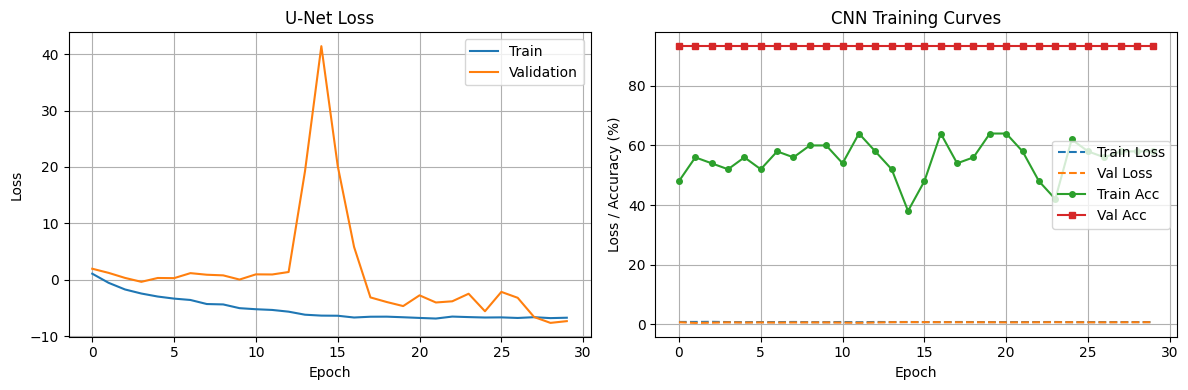


=== Test Set Metrics ===
Accuracy:  26.67%
Precision: 0.2667
Recall:    1.0000
F1-score:  0.4211

Confusion Matrix:
[[ 0 11]
 [ 0  4]]


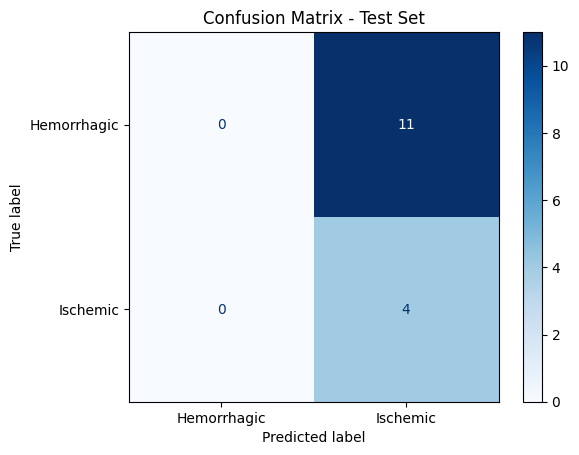


Classification Report:
              precision    recall  f1-score   support

 Hemorrhagic       0.00      0.00      0.00        11
    Ischemic       0.27      1.00      0.42         4

    accuracy                           0.27        15
   macro avg       0.13      0.50      0.21        15
weighted avg       0.07      0.27      0.11        15



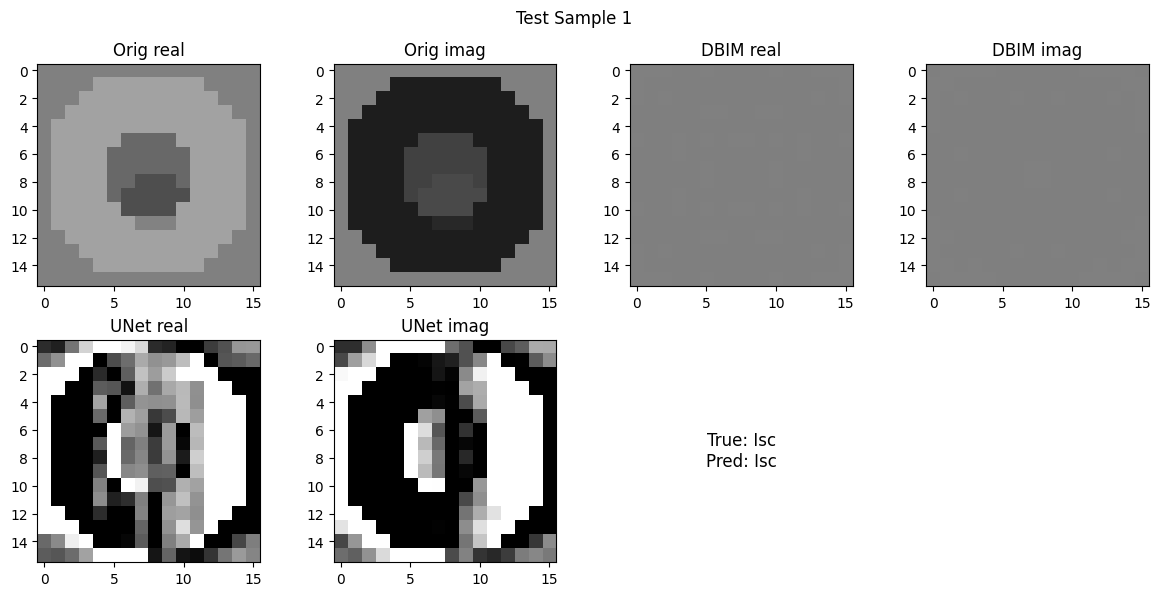

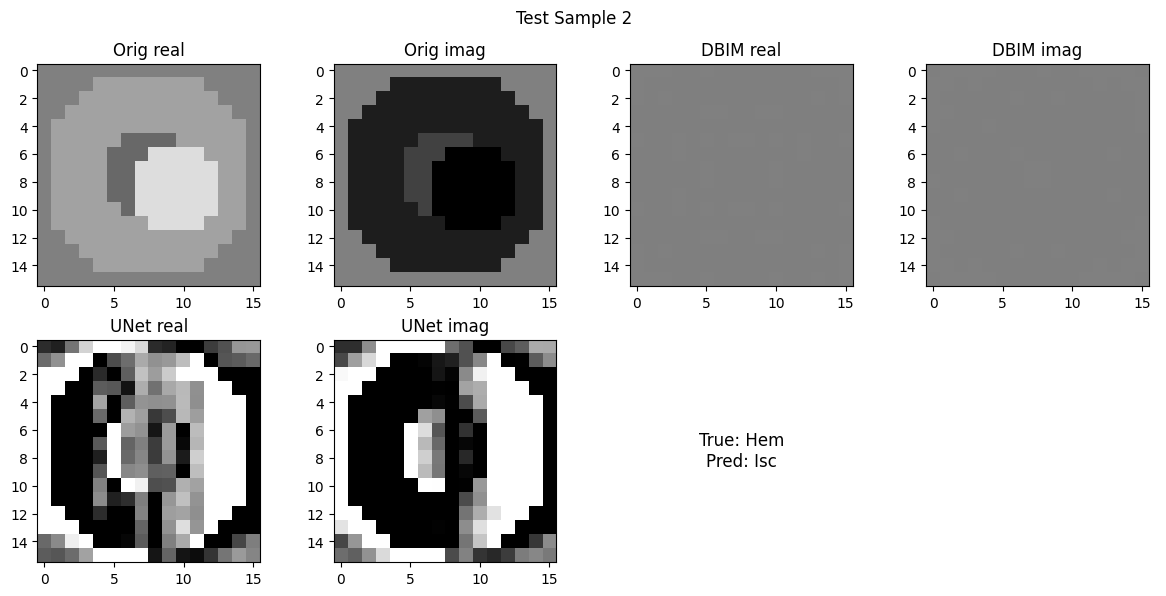

In [ ]:
# =============================================================================
# Fast implementation with evaluation metrics and plots
# =============================================================================

import numpy as np
import scipy.special as sp
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from scipy.linalg import solve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# ---------------------------
# 1. Physics (same as before)
# ---------------------------
def green_2d(r, rp, k0):
    dist = np.linalg.norm(r - rp)
    if dist < 1e-12:
        return -1j / 4 * (1 - 2j / np.pi * (np.log(k0 * 1e-12 / 2) + 0.5772))
    return -1j / 4 * sp.hankel2(0, k0 * dist)

def build_matrices(pixels, receivers, transmitters, k0):
    N = len(pixels); R = len(receivers)
    GD = np.zeros((N, N), dtype=complex)
    Gs = np.zeros((R, N), dtype=complex)
    for i, pi in enumerate(pixels):
        for j, pj in enumerate(pixels):
            GD[i, j] = green_2d(pi, pj, k0)
        for r, rec in enumerate(receivers):
            Gs[r, i] = green_2d(rec, pi, k0)
    return GD, Gs

def forward_solver(GD, chi, E_inc):
    N = chi.shape[0]; T = E_inc.shape[1]
    A = np.eye(N, dtype=complex) - GD @ np.diag(chi)
    E_tot = np.zeros((N, T), dtype=complex)
    for t in range(T):
        E_tot[:, t] = solve(A, E_inc[:, t])
    return E_tot

def dbim_reconstruct(E_scat, GD, Gs, E_inc, lambda_reg=0.001, max_iter=3):
    N = GD.shape[0]; T = E_inc.shape[1]
    chi = np.zeros(N, dtype=complex)
    for it in range(max_iter):
        E_tot = forward_solver(GD, chi, E_inc)
        E_s_pred = Gs @ (chi[:, np.newaxis] * E_tot)
        resid = E_scat - E_s_pred
        invA = np.linalg.inv(np.eye(N, dtype=complex) - GD @ np.diag(chi))
        G_bs = Gs @ invA
        dchi = np.zeros(N, dtype=complex)
        for t in range(T):
            Jt = G_bs * E_tot[:, t]
            JtH = Jt.conj().T
            A = JtH @ Jt + lambda_reg * np.eye(N, dtype=complex)
            b = JtH @ resid[:, t]
            dchi += solve(A, b)
        chi = chi + dchi / T
        chi.real = np.clip(chi.real, -1, 1)
    return chi

def generate_phantom(size, stroke_type, head_radius=0.08):
    Nx, Ny = size
    x = np.linspace(-head_radius, head_radius, Nx)
    y = np.linspace(-head_radius, head_radius, Ny)
    X, Y = np.meshgrid(x, y, indexing='ij')
    head = (X**2 + Y**2) <= head_radius**2
    white = ((X/0.7)**2 + (Y/0.7)**2) <= (0.6*head_radius)**2
    gray = head & ~white

    eps_b = 44.0
    eps_gray, sigma_gray = 50.0, 0.8
    eps_white, sigma_white = 40.0, 0.5
    eps_blood, sigma_blood = 60.0, 1.2

    eps = np.ones((Nx, Ny)) * eps_b
    sigma = np.zeros((Nx, Ny))
    eps[gray] = eps_gray; sigma[gray] = sigma_gray
    eps[white] = eps_white; sigma[white] = sigma_white

    pos = (np.random.uniform(-0.3*head_radius, 0.3*head_radius),
           np.random.uniform(-0.3*head_radius, 0.3*head_radius))
    radius = np.random.uniform(0.02, 0.04)
    stroke = ((X - pos[0])**2 + (Y - pos[1])**2) <= radius**2

    if stroke_type == 'hemorrhagic':
        eps[stroke] = eps_blood
        sigma[stroke] = sigma_blood
    else:
        reduction = np.random.normal(0.17, 0.07)
        eps[stroke] = eps[stroke] * (1 - reduction)
        sigma[stroke] = sigma[stroke] * (1 - reduction)

    omega = 2 * np.pi * 0.85e9
    eps0 = 8.854e-12
    chi_real = eps / eps_b - 1.0
    chi_imag = - sigma / (omega * eps0 * eps_b)
    return chi_real, chi_imag, stroke

def simulate_scattering(chi_real, chi_imag, GD, Gs, transmitters, receivers, k0, pixels, SNR=30):
    N = chi_real.size; T = len(transmitters)
    chi = chi_real.flatten() + 1j * chi_imag.flatten()
    E_inc = np.zeros((N, T), dtype=complex)
    for t, tx in enumerate(transmitters):
        for i, px in enumerate(pixels):
            E_inc[i, t] = green_2d(tx, px, k0)
    E_tot = forward_solver(GD, chi, E_inc)
    E_scat = Gs @ (chi[:, np.newaxis] * E_tot)
    if SNR is not None:
        signal_power = np.mean(np.abs(E_scat)**2)
        noise_power = signal_power / (10**(SNR/10))
        noise = np.sqrt(noise_power/2) * (np.random.randn(*E_scat.shape) + 1j * np.random.randn(*E_scat.shape))
        E_scat += noise
    return E_scat, E_inc

# ---------------------------
# 2. U‑Net (3 stages, safe)
# ---------------------------
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_ch=2, out_ch=2):
        super().__init__()
        self.enc1 = DoubleConv(in_ch, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(128, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64, 32)
        self.out = nn.Conv2d(32, out_ch, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))
        d3 = self.up3(b); d3 = torch.cat((d3, e3), dim=1); d3 = self.dec3(d3)
        d2 = self.up2(d3); d2 = torch.cat((d2, e2), dim=1); d2 = self.dec2(d2)
        d1 = self.up1(d2); d1 = torch.cat((d1, e1), dim=1); d1 = self.dec1(d1)
        return self.out(d1)

# ---------------------------
# 3. CNN Classifier
# ---------------------------
class StrokeClassifier(nn.Module):
    def __init__(self, in_ch=2, input_size=16):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_ch, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc_input = 64 * (input_size // 8) * (input_size // 8)
        self.fc1 = nn.Linear(self.fc_input, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        self.drop = nn.Dropout(0.5)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.drop(x)
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# ---------------------------
# 4. Loss functions
# ---------------------------
def ssim_loss(img1, img2, window_size=7):
    C = img1.size(1)
    device = img1.device
    kernel = torch.ones(1, 1, window_size, window_size, device=device) / (window_size**2)
    pad = window_size // 2
    c1, c2 = 0.01**2, 0.03**2
    def stats(x):
        mu = F.conv2d(x, kernel, padding=pad, groups=C)
        mu_sq = mu**2
        sigma_sq = F.conv2d(x**2, kernel, padding=pad, groups=C) - mu_sq
        return mu, mu_sq, sigma_sq
    mu1, mu1_sq, sigma1_sq = stats(img1)
    mu2, mu2_sq, sigma2_sq = stats(img2)
    mu12 = mu1 * mu2
    sigma12 = F.conv2d(img1 * img2, kernel, padding=pad, groups=C) - mu12
    ssim = ((2*mu12 + c1)*(2*sigma12 + c2)) / ((mu1_sq + mu2_sq + c1)*(sigma2_sq + sigma2_sq + c2))
    return 1 - ssim.mean()

def combined_loss(pred, target):
    return (ssim_loss(pred[:,0:1], target[:,0:1]) +
            ssim_loss(pred[:,1:2], target[:,1:2]) +
            F.l1_loss(pred, target) +
            F.mse_loss(pred, target))

# ---------------------------
# 5. Main execution with metrics
# ---------------------------
if __name__ == "__main__":
    # Parameters
    head_radius = 0.08
    antenna_radius = 0.10
    grid_size = (16, 16)
    num_antennas = 16
    freq = 0.85e9
    omega = 2 * np.pi * freq
    eps0 = 8.854e-12
    eps_b = 44.0
    k0 = omega * np.sqrt(eps_b * eps0)

    Nx, Ny = grid_size
    x = np.linspace(-head_radius, head_radius, Nx)
    y = np.linspace(-head_radius, head_radius, Ny)
    X, Y = np.meshgrid(x, y, indexing='ij')
    pixels = np.stack([X.flatten(), Y.flatten()], axis=-1)

    angles = np.linspace(0, 2*np.pi, num_antennas, endpoint=False)
    positions = antenna_radius * np.array([np.cos(angles), np.sin(angles)]).T
    transmitters = receivers = positions

    print("Building Green's matrices...")
    GD, Gs = build_matrices(pixels, receivers, transmitters, k0)
    print("Done.")

    # Generate dataset
    num_samples = 80
    num_train, num_val, num_test = 50, 15, 15
    np.random.seed(42)

    X_dbim, X_orig, y = [], [], []
    for i in range(num_samples):
        stype = np.random.choice(['hemorrhagic', 'ischemic'])
        label = 0 if stype == 'hemorrhagic' else 1
        chi_real, chi_imag, _ = generate_phantom(grid_size, stype, head_radius)
        E_scat, E_inc = simulate_scattering(chi_real, chi_imag, GD, Gs,
                                            transmitters, receivers, k0, pixels, SNR=30)
        chi_recon = dbim_reconstruct(E_scat, GD, Gs, E_inc, max_iter=3)
        chi_recon = chi_recon.reshape(grid_size)
        X_dbim.append(np.stack([chi_recon.real, chi_recon.imag], axis=0))
        X_orig.append(np.stack([chi_real, chi_imag], axis=0))
        y.append(label)
        if (i+1) % 20 == 0:
            print(f"Generated {i+1}/{num_samples}")

    X_dbim = np.array(X_dbim)
    X_orig = np.array(X_orig)
    y = np.array(y)

    idx = np.random.permutation(num_samples)
    train_idx = idx[:num_train]
    val_idx = idx[num_train:num_train+num_val]
    test_idx = idx[num_train+num_val:]

    X_train, y_train = X_dbim[train_idx], y[train_idx]
    X_val, y_val = X_dbim[val_idx], y[val_idx]
    X_test, y_test = X_dbim[test_idx], y[test_idx]
    X_orig_train, X_orig_val = X_orig[train_idx], X_orig[val_idx]

    # Tensors
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1,1)
    X_orig_train_t = torch.tensor(X_orig_train, dtype=torch.float32)
    X_orig_val_t = torch.tensor(X_orig_val, dtype=torch.float32)

    batch_size = 8
    train_loader = DataLoader(TensorDataset(X_train_t, X_orig_train_t),
                              batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_t, X_orig_val_t),
                            batch_size=batch_size, shuffle=False)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print("Using device:", device)

    # ----------------------------
    # Train U‑Net with loss tracking
    # ----------------------------
    unet = UNet().to(device)
    opt = optim.Adam(unet.parameters(), lr=0.003)
    scheduler = optim.lr_scheduler.StepLR(opt, step_size=15, gamma=0.1)
    epochs = 30

    unet_train_loss = []
    unet_val_loss = []

    print("Training U‑Net (30 epochs)...")
    for ep in range(epochs):
        unet.train()
        loss_train = 0
        for inp, tgt in train_loader:
            inp, tgt = inp.to(device), tgt.to(device)
            opt.zero_grad()
            out = unet(inp)
            loss = combined_loss(out, tgt)
            loss.backward()
            opt.step()
            loss_train += loss.item()
        scheduler.step()
        unet_train_loss.append(loss_train / len(train_loader))

        unet.eval()
        loss_val = 0
        with torch.no_grad():
            for inp, tgt in val_loader:
                inp, tgt = inp.to(device), tgt.to(device)
                out = unet(inp)
                loss_val += combined_loss(out, tgt).item()
        unet_val_loss.append(loss_val / len(val_loader))

        if (ep+1) % 10 == 0:
            print(f"Epoch {ep+1}/{epochs}, Train Loss: {unet_train_loss[-1]:.4f}, Val Loss: {unet_val_loss[-1]:.4f}")

    # ----------------------------
    # Prepare U‑Net outputs for CNN
    # ----------------------------
    unet.eval()
    with torch.no_grad():
        X_train_unet = unet(X_train_t.to(device)).cpu().numpy()
        X_val_unet = unet(X_val_t.to(device)).cpu().numpy()
        X_test_unet = unet(X_test_t.to(device)).cpu().numpy()

    X_train_cnn = torch.tensor(X_train_unet, dtype=torch.float32)
    X_val_cnn = torch.tensor(X_val_unet, dtype=torch.float32)
    X_test_cnn = torch.tensor(X_test_unet, dtype=torch.float32)

    train_cnn_loader = DataLoader(TensorDataset(X_train_cnn, y_train_t),
                                  batch_size=batch_size, shuffle=True)
    val_cnn_loader = DataLoader(TensorDataset(X_val_cnn, y_val_t),
                                batch_size=batch_size, shuffle=False)
    test_cnn_loader = DataLoader(TensorDataset(X_test_cnn, y_test_t),
                                 batch_size=batch_size, shuffle=False)

    # ----------------------------
    # Train CNN with loss & accuracy tracking
    # ----------------------------
    classifier = StrokeClassifier(input_size=Nx).to(device)
    opt = optim.Adam(classifier.parameters(), lr=0.003)
    scheduler = optim.lr_scheduler.StepLR(opt, step_size=15, gamma=0.5)
    criterion = nn.BCEWithLogitsLoss()
    epochs_cnn = 30

    cnn_train_loss = []
    cnn_val_loss = []
    cnn_train_acc = []
    cnn_val_acc = []

    print("Training CNN (30 epochs)...")
    for ep in range(epochs_cnn):
        classifier.train()
        loss_train = 0
        correct, total = 0, 0
        for inp, lab in train_cnn_loader:
            inp, lab = inp.to(device), lab.to(device)
            opt.zero_grad()
            out = classifier(inp)
            loss = criterion(out, lab)
            loss.backward()
            opt.step()
            loss_train += loss.item()
            pred = (torch.sigmoid(out) > 0.5).float()
            correct += (pred == lab).sum().item()
            total += lab.size(0)
        scheduler.step()
        train_acc = 100 * correct / total
        cnn_train_loss.append(loss_train / len(train_cnn_loader))
        cnn_train_acc.append(train_acc)

        classifier.eval()
        loss_val = 0
        correct_v, total_v = 0, 0
        with torch.no_grad():
            for inp, lab in val_cnn_loader:
                inp, lab = inp.to(device), lab.to(device)
                out = classifier(inp)
                loss_val += criterion(out, lab).item()
                pred = (torch.sigmoid(out) > 0.5).float()
                correct_v += (pred == lab).sum().item()
                total_v += lab.size(0)
        val_acc = 100 * correct_v / total_v
        cnn_val_loss.append(loss_val / len(val_cnn_loader))
        cnn_val_acc.append(val_acc)

        if (ep+1) % 10 == 0:
            print(f"Epoch {ep+1}/{epochs_cnn}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

    # ----------------------------
    # Plot U‑Net losses
    # ----------------------------
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(unet_train_loss, label='Train')
    plt.plot(unet_val_loss, label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('U‑Net Loss')
    plt.legend()
    plt.grid(True)

    # Plot CNN loss and accuracy
    plt.subplot(1, 2, 2)
    plt.plot(cnn_train_loss, label='Train Loss', linestyle='--')
    plt.plot(cnn_val_loss, label='Val Loss', linestyle='--')
    plt.plot(cnn_train_acc, label='Train Acc', marker='o', markersize=4)
    plt.plot(cnn_val_acc, label='Val Acc', marker='s', markersize=4)
    plt.xlabel('Epoch')
    plt.ylabel('Loss / Accuracy (%)')
    plt.title('CNN Training Curves')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ----------------------------
    # Test evaluation with metrics
    # ----------------------------
    classifier.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inp, lab in test_cnn_loader:
            inp, lab = inp.to(device), lab.to(device)
            out = classifier(inp)
            pred = (torch.sigmoid(out) > 0.5).float()
            all_preds.extend(pred.cpu().numpy().flatten().tolist())
            all_labels.extend(lab.cpu().numpy().flatten().tolist())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)

    print("\n=== Test Set Metrics ===")
    print(f"Accuracy:  {acc*100:.2f}%")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print("\nConfusion Matrix:")
    print(cm)
    # Display confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Hemorrhagic', 'Ischemic'])
    disp.plot(cmap='Blues')
    plt.title('Confusion Matrix - Test Set')
    plt.show()

    # Also print a classification report
    from sklearn.metrics import classification_report
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=['Hemorrhagic', 'Ischemic']))

    # ----------------------------
    # Display sample images
    # ----------------------------
    X_orig_test = X_orig[test_idx]
    y_test_arr = y[test_idx]
    num_show = 2
    for i in range(num_show):
        fig, axes = plt.subplots(2, 4, figsize=(12, 6))
        # Original
        axes[0,0].imshow(X_orig_test[i][0], cmap='gray', vmin=-0.5, vmax=0.5)
        axes[0,0].set_title('Orig real')
        axes[0,1].imshow(X_orig_test[i][1], cmap='gray', vmin=-0.5, vmax=0.5)
        axes[0,1].set_title('Orig imag')
        # DBIM
        axes[0,2].imshow(X_test[i][0], cmap='gray', vmin=-0.5, vmax=0.5)
        axes[0,2].set_title('DBIM real')
        axes[0,3].imshow(X_test[i][1], cmap='gray', vmin=-0.5, vmax=0.5)
        axes[0,3].set_title('DBIM imag')
        # U‑Net
        axes[1,0].imshow(X_test_unet[i][0], cmap='gray', vmin=-0.5, vmax=0.5)
        axes[1,0].set_title('UNet real')
        axes[1,1].imshow(X_test_unet[i][1], cmap='gray', vmin=-0.5, vmax=0.5)
        axes[1,1].set_title('UNet imag')
        # Labels
        true_l = 'Hem' if y_test_arr[i] == 0 else 'Isc'
        pred_l = 'Hem' if all_preds[i] == 0 else 'Isc'
        axes[1,2].text(0.5, 0.5, f'True: {true_l}\nPred: {pred_l}',
                       ha='center', va='center', fontsize=12)
        axes[1,2].axis('off')
        axes[1,3].axis('off')
        plt.suptitle(f'Test Sample {i+1}')
        plt.tight_layout()
        plt.show()